<a href="https://colab.research.google.com/github/rsdina/Recommender_System_Assignment_488/blob/main/Music_Recommender_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INSTALL REQUIRED PACKAGES

In [13]:
!pip install -q streamlit streamlit-aggrid pyngrok pandas numpy scikit-learn scipy matplotlib seaborn plotly

print("All packages installed!")

All packages installed!


#DOWNLOAD DATASET (Last.fm 360K)

In [14]:
import os
import urllib.request
import tarfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Downloading Last.fm 360K dataset...")
print("This may take 5-10 minutes. File size is ~300MB.\n")

# Download the dataset
url = "http://mtg.upf.edu/static/datasets/last.fm/lastfm-dataset-360K.tar.gz"
filename = "lastfm-dataset-360K.tar.gz"

if not os.path.exists(filename):
    # Create a Request object with a User-Agent header
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(filename, 'wb') as out_file:
        out_file.write(response.read())
    print("Download complete!")

# Extract the dataset
if not os.path.exists("lastfm-dataset-360K"):
    print("Extracting files...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete!")

# Load the data
data_path = "lastfm-dataset-360K"

# Load user-artist interactions (listening counts)
listening_file = os.path.join(data_path, "usersha1-artmbid-artname-plays.tsv")
listening_df = pd.read_csv(listening_file, sep='\t', header=None,
                            names=['user_id', 'musicbrainz_id', 'artist_name', 'plays'],
                            nrows=50000)  # Using 50k rows for faster processing

# Load user profiles
profile_file = os.path.join(data_path, "usersha1-profile.tsv")
user_profiles = pd.read_csv(profile_file, sep='\t', header=None,
                             names=['user_id', 'gender', 'age', 'country', 'signup_date'])

print(f"\nDataset loaded successfully!")
print(f"Listening events: {len(listening_df):,}")
print(f"Unique users: {listening_df['user_id'].nunique():,}")
print(f"Unique artists: {listening_df['artist_name'].nunique():,}")

This may take 5-10 minutes. File size is ~300MB.


Dataset loaded successfully!
Listening events: 50,000
Unique users: 1,015
Unique artists: 15,967


# DATA PREPROCESSING

In [15]:
print("\nPreprocessing data...")

# Clean the data
listening_df = listening_df.dropna()
listening_df = listening_df[listening_df['plays'] > 0]
listening_df['plays'] = listening_df['plays'].clip(upper=100)  # Cap extreme values

# Create user ID mapping
user_ids = listening_df['user_id'].unique()
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
artist_names = listening_df['artist_name'].unique()
artist_to_idx = {artist: i for i, artist in enumerate(artist_names)}

listening_df['user_idx'] = listening_df['user_id'].map(user_to_idx)
listening_df['artist_idx'] = listening_df['artist_name'].map(artist_to_idx)

# Create user-artist matrix (sparse)
from scipy.sparse import coo_matrix, csr_matrix

n_users = len(user_ids)
n_artists = len(artist_names)

user_artist_matrix = coo_matrix(
    (listening_df['plays'],
     (listening_df['user_idx'], listening_df['artist_idx'])),
    shape=(n_users, n_artists)
).tocsr()

print(f"User-Artist Matrix created!")
print(f"Shape: {user_artist_matrix.shape}")
print(f"Sparsity: {(1 - user_artist_matrix.nnz / (n_users * n_artists)) * 100:.2f}%")

# Create artist metadata dataframe
artist_stats = listening_df.groupby('artist_name').agg({
    'plays': ['sum', 'count', 'mean']
}).round(2)
artist_stats.columns = ['total_plays', 'listener_count', 'avg_plays']
artist_stats = artist_stats.reset_index()
artist_stats = artist_stats.sort_values('total_plays', ascending=False)

print(f"\nTop 10 Most Listened Artists:")
print(artist_stats.head(10).to_string(index=False))


Preprocessing data...
User-Artist Matrix created!
Shape: (1015, 15363)
Sparsity: 99.68%

Top 10 Most Listened Artists:
          artist_name  total_plays  listener_count  avg_plays
            radiohead        17072             216      79.04
          the beatles        15790             188      83.99
             coldplay        13120             173      75.84
red hot chili peppers        11250             146      77.05
                 muse         9670             121      79.92
            metallica         9243             115      80.37
     system of a down         8898             116      76.71
          linkin park         8744             108      80.96
           pink floyd         8104             106      76.45
              nirvana         8104             116      69.86


# KNOWLEDGE-BASED RECOMMENDER (Collaborative Filtering)

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

class KnowledgeBasedRecommender:
    """Knowledge-based recommender using user-user collaborative filtering"""

    def __init__(self, user_artist_matrix, artist_names, artist_stats):
        self.user_artist_matrix = user_artist_matrix
        self.artist_names = artist_names
        self.artist_stats = artist_stats

    def get_user_history(self, user_idx):
        """Get user's listening history"""
        user_vector = self.user_artist_matrix[user_idx].toarray().flatten()
        listened_artists = [self.artist_names[i] for i in range(len(user_vector)) if user_vector[i] > 0]
        return listened_artists

    def find_similar_users(self, user_idx, n_similar=10):
        """Find similar users based on cosine similarity"""
        user_vector = self.user_artist_matrix[user_idx].toarray().reshape(1, -1)
        similarities = cosine_similarity(user_vector, self.user_artist_matrix).flatten()
        similarities[user_idx] = -1
        similar_users = np.argsort(similarities)[::-1][:n_similar]
        return similar_users, similarities[similar_users]

    def recommend(self, user_idx, n_recommendations=10, n_similar_users=10):
        """Generate recommendations based on similar users' listening habits"""
        similar_users, similarities = self.find_similar_users(user_idx, n_similar_users)

        # Get user's already listened artists
        user_listened = set(self.get_user_history(user_idx))

        # Aggregate recommendations from similar users
        recommendations = {}
        for sim_user, sim_score in zip(similar_users, similarities):
            if sim_score <= 0:
                continue
            user_vector = self.user_artist_matrix[sim_user].toarray().flatten()
            for artist_idx, plays in enumerate(user_vector):
                if plays > 0 and self.artist_names[artist_idx] not in user_listened:
                    if artist_idx not in recommendations:
                        recommendations[artist_idx] = {'score': 0, 'count': 0}
                    recommendations[artist_idx]['score'] += plays * sim_score
                    recommendations[artist_idx]['count'] += 1

        # Calculate weighted scores and sort
        rec_list = []
        for artist_idx, data in recommendations.items():
            weighted_score = data['score'] / data['count']
            rec_list.append({
                'artist_idx': artist_idx,
                'artist_name': self.artist_names[artist_idx],
                'score': weighted_score
            })

        rec_list.sort(key=lambda x: x['score'], reverse=True)

        # Add metadata
        results = []
        for rec in rec_list[:n_recommendations]:
            artist_info = self.artist_stats[self.artist_stats['artist_name'] == rec['artist_name']]
            if len(artist_info) > 0:
                rec['total_plays'] = artist_info['total_plays'].values[0]
                rec['listener_count'] = artist_info['listener_count'].values[0]
            results.append(rec)

        return results

print("Knowledge-Based Recommender initialized!")

Knowledge-Based Recommender initialized!


# REINFORCEMENT LEARNING RECOMMENDER (Q-Learning)

In [17]:
class MusicQLearningAgent:
    """Q-Learning Agent for personalized music recommendations"""

    def __init__(self, n_artists, learning_rate=0.1, discount_factor=0.95, epsilon=0.2):
        self.n_artists = n_artists
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.q_table = np.random.rand(n_artists) * 0.01
        self.update_counts = np.zeros(n_artists)
        self.reward_history = []

    def choose_action(self, user_history_set=None):
        """Epsilon-greedy action selection with optional exploration bias"""
        if np.random.random() < self.epsilon:
            # Exploration: prefer artists not in history
            if user_history_set and len(user_history_set) < self.n_artists:
                available = [i for i in range(self.n_artists) if i not in user_history_set]
                if available:
                    return np.random.choice(available)
            return np.random.randint(self.n_artists)
        else:
            # Exploitation: choose highest Q-value
            return np.argmax(self.q_table)

    def update(self, action, reward):
        """Update Q-value using Q-learning update rule"""
        # Normalize reward (plays: 1-100 to 0-1 range)
        normalized_reward = min(reward / 100.0, 1.0)

        current_q = self.q_table[action]
        new_q = current_q + self.lr * (normalized_reward + self.gamma * np.max(self.q_table) - current_q)
        self.q_table[action] = new_q
        self.update_counts[action] += 1

        return new_q - current_q  # Return TD error for monitoring

    def decay_epsilon(self, decay_rate=0.995, min_epsilon=0.01):
        """Decay exploration rate over time"""
        self.epsilon = max(self.epsilon * decay_rate, min_epsilon)

    def get_top_recommendations(self, n=10, exclude_set=None):
        """Get top-N recommendations by Q-value"""
        q_values = self.q_table.copy()
        if exclude_set:
            for idx in exclude_set:
                q_values[idx] = -np.inf
        top_indices = np.argsort(q_values)[::-1][:n]
        return top_indices, self.q_table[top_indices]

print("Q-Learning Agent initialized!")

Q-Learning Agent initialized!


# TRAIN THE Q-LEARNING AGENT

In [18]:
print("\nTraining Q-Learning Agent...")

# Select a test user
test_user_idx = np.random.randint(0, n_users)
test_user_id = user_ids[test_user_idx]

# Get user's listening history for training
user_vector = user_artist_matrix[test_user_idx].toarray().flatten()
user_history = [(i, user_vector[i]) for i in range(n_artists) if user_vector[i] > 0]
user_history_set = set(i for i, _ in user_history)

print(f"Test User: {test_user_id[:20]}...")
print(f"Artists listened: {len(user_history)}")
print(f"Average plays: {np.mean([p for _, p in user_history]):.2f}")

# Initialize agent
agent = MusicQLearningAgent(n_artists, learning_rate=0.15, epsilon=0.3)

# Training parameters
n_episodes = 30
episode_rewards = []
td_errors = []

for episode in range(n_episodes):
    episode_total_reward = 0
    episode_td_errors = []

    for _ in range(min(50, len(user_history))):
        # Choose action
        action = agent.choose_action(user_history_set)

        # Get reward (play count if listened, else 0)
        if action in user_history_set:
            reward = user_vector[action]
        else:
            reward = 0

        # Update Q-value
        td_error = agent.update(action, reward)

        episode_total_reward += reward
        episode_td_errors.append(td_error)

    episode_rewards.append(episode_total_reward)
    td_errors.append(np.mean(episode_td_errors))
    agent.decay_epsilon(decay_rate=0.97)

    if (episode + 1) % 10 == 0:
        print(f"Episode {episode + 1}/{n_episodes} - Total Reward: {episode_total_reward:.0f} - Epsilon: {agent.epsilon:.3f}")

print("Training Complete!")


Training Q-Learning Agent...
Test User: 003ccc592a9e549af7ba...
Artists listened: 53
Average plays: 100.00
Episode 10/30 - Total Reward: 0 - Epsilon: 0.221
Episode 20/30 - Total Reward: 0 - Epsilon: 0.163
Episode 30/30 - Total Reward: 4600 - Epsilon: 0.120
Training Complete!


# GENERATE RECOMMENDATIONS

In [19]:
# Initialize knowledge-based recommender
kb_recommender = KnowledgeBasedRecommender(user_artist_matrix, artist_names, artist_stats)

print("\n" + "="*80)
print(f"KNOWLEDGE-BASED RECOMMENDATIONS")
print("="*80 + "\n")

kb_recs = kb_recommender.recommend(test_user_idx, n_recommendations=10)

for i, rec in enumerate(kb_recs, 1):
    print(f"{i:2d}. {rec['artist_name'][:50]:50s} | Score: {rec['score']:.4f}")
    print(f"    Total Plays: {rec.get('total_plays', 'N/A'):,.0f} | Listeners: {rec.get('listener_count', 'N/A'):,}")
    print()

print("\n" + "="*80)
print(f"REINFORCEMENT LEARNING RECOMMENDATIONS (Q-Learning)")
print("="*80 + "\n")

rl_recs_indices, rl_scores = agent.get_top_recommendations(n=10, exclude_set=user_history_set)

for i, (artist_idx, score) in enumerate(zip(rl_recs_indices, rl_scores), 1):
    artist_name = artist_names[artist_idx]
    is_new = " NEW" if artist_idx not in user_history_set else "  LISTENED"
    print(f"{i:2d}. {artist_name[:50]:50s} {is_new}")
    print(f"    Q-Value: {score:.6f}")
    print()

print("\n" + "="*80)
print(f"HYBRID RECOMMENDATIONS (40% KB + 60% RL)")
print("="*80 + "\n")

# Create hybrid recommendations
kb_dict = {rec['artist_name']: rec['score'] for rec in kb_recs}
rl_dict = {artist_names[idx]: score for idx, score in zip(rl_recs_indices, rl_scores)}

all_artists = set(kb_dict.keys()) | set(rl_dict.keys())
hybrid_recs = []

for artist in all_artists:
    kb_score = kb_dict.get(artist, 0)
    rl_score = rl_dict.get(artist, 0)

    # Normalize scores
    if kb_dict:
        kb_norm = kb_score / max(kb_dict.values())
    else:
        kb_norm = 0
    if rl_dict:
        rl_norm = rl_score / max(rl_dict.values())
    else:
        rl_norm = 0

    hybrid_score = 0.4 * kb_norm + 0.6 * rl_norm
    hybrid_recs.append({'artist_name': artist, 'hybrid_score': hybrid_score,
                        'kb_score': kb_norm, 'rl_score': rl_norm})

hybrid_recs.sort(key=lambda x: x['hybrid_score'], reverse=True)

for i, rec in enumerate(hybrid_recs[:10], 1):
    print(f"{i:2d}. {rec['artist_name'][:50]:50s} | Hybrid: {rec['hybrid_score']:.4f}")
    print(f"    KB Contribution: {rec['kb_score']:.4f} | RL Contribution: {rec['rl_score']:.4f}")
    print()


KNOWLEDGE-BASED RECOMMENDATIONS

 1. tool                                               | Score: 21.3683
    Total Plays: 4,863 | Listeners: 63

 2. four tet                                           | Score: 21.3683
    Total Plays: 1,785 | Listeners: 21

 3. the hold steady                                    | Score: 21.3683
    Total Plays: 700 | Listeners: 7

 4. clutch                                             | Score: 21.3683
    Total Plays: 646 | Listeners: 8

 5. white denim                                        | Score: 21.3683
    Total Plays: 184 | Listeners: 3

 6. 2 many dj's                                        | Score: 21.3683
    Total Plays: 200 | Listeners: 2

 7. tv on the radio                                    | Score: 21.3683
    Total Plays: 1,699 | Listeners: 24

 8. kyuss                                              | Score: 21.3683
    Total Plays: 667 | Listeners: 8

 9. a tribe called quest                               | Score: 21.3683
    Total Pla

# VISUALIZATIONS


Generating Visualizations...


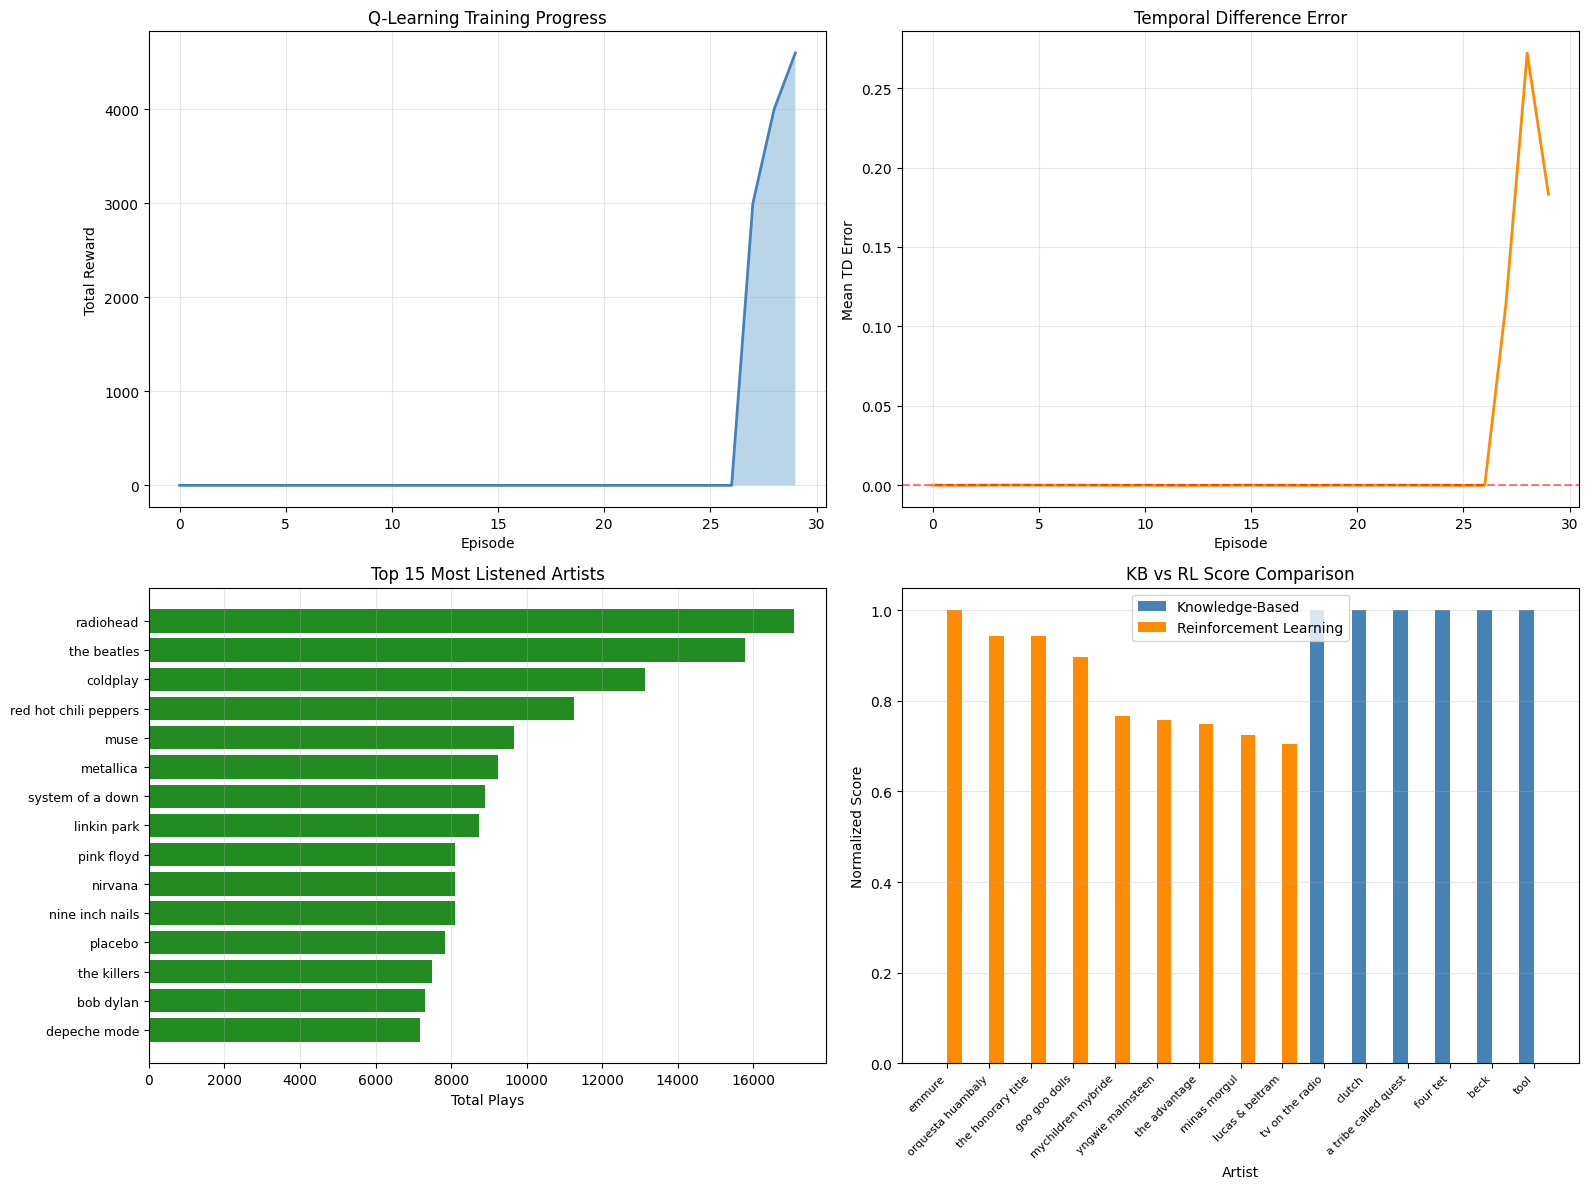

Visualizations complete!


In [20]:
print("\nGenerating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training Progress
axes[0, 0].plot(episode_rewards, linewidth=2, color='steelblue')
axes[0, 0].fill_between(range(len(episode_rewards)), episode_rewards, alpha=0.3)
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Q-Learning Training Progress')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: TD Errors
axes[0, 1].plot(td_errors, linewidth=2, color='darkorange')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Mean TD Error')
axes[0, 1].set_title('Temporal Difference Error')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Top Artists by Listens
top_artists = artist_stats.head(15)
axes[1, 0].barh(range(len(top_artists)), top_artists['total_plays'].values, color='forestgreen')
axes[1, 0].set_yticks(range(len(top_artists)))
axes[1, 0].set_yticklabels(top_artists['artist_name'].values, fontsize=9)
axes[1, 0].set_xlabel('Total Plays')
axes[1, 0].set_title('Top 15 Most Listened Artists')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: KB vs RL Score Comparison
comparison_data = []
for rec in hybrid_recs[:15]:
    comparison_data.append({
        'artist': rec['artist_name'][:25],
        'KB': rec['kb_score'],
        'RL': rec['rl_score']
    })
comp_df = pd.DataFrame(comparison_data)
x = np.arange(len(comp_df))
width = 0.35
axes[1, 1].bar(x - width/2, comp_df['KB'], width, label='Knowledge-Based', color='steelblue')
axes[1, 1].bar(x + width/2, comp_df['RL'], width, label='Reinforcement Learning', color='darkorange')
axes[1, 1].set_xlabel('Artist')
axes[1, 1].set_ylabel('Normalized Score')
axes[1, 1].set_title('KB vs RL Score Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comp_df['artist'], rotation=45, ha='right', fontsize=8)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations complete!")

#Dashboard of Music Recommender

In [22]:

import json, numpy as np, pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, HTML

# ─────────────────────────────────────────────────────────────────────
# STEP 1 ── Pre-bake ALL user-level data into a JSON lookup table.
#           This lets the dashboard switch users instantly in-browser
#           without any further Python calls.
# ─────────────────────────────────────────────────────────────────────


N_RECS      = 10          # recommendations per user
N_SIM_USERS = 10          # similar users for KB

def _kb_scores_for_user(u_idx):
    """Pure collaborative-filtering scores for one user (dict artist→score)."""
    uv = user_artist_matrix[u_idx].toarray().flatten()
    listened = set(int(i) for i in np.nonzero(uv)[0])
    sim = cosine_similarity(uv.reshape(1,-1), user_artist_matrix).flatten()
    sim[u_idx] = -1
    top_sim_users = np.argsort(sim)[::-1][:N_SIM_USERS]
    scores = {}
    for su in top_sim_users:
        if sim[su] <= 0: continue
        sv = user_artist_matrix[su].toarray().flatten()
        for ai, plays in enumerate(sv):
            if plays > 0 and ai not in listened:
                scores[ai] = scores.get(ai, 0) + plays * sim[su]
    return scores, listened

def _hybrid_for_user(u_idx, kb_w=0.4):
    """Return top-N hybrid recommendations as list of dicts."""
    kb_raw, listened = _kb_scores_for_user(u_idx)
    uv = user_artist_matrix[u_idx].toarray().flatten()

    # Normalise KB
    max_kb = max(kb_raw.values()) if kb_raw else 1
    kb_norm = {ai: v/max_kb for ai,v in kb_raw.items()}

    # RL scores from q_table (already trained)
    rl_all = agent.q_table.copy()

    # Combine
    all_idx = set(kb_norm.keys()) | set(range(len(artist_names)))
    rows = []
    for ai in all_idx:
        if ai in listened: continue
        kb_s = kb_norm.get(ai, 0)
        rl_s = float(rl_all[ai]) / (float(np.max(rl_all)) + 1e-9)
        h    = (1-kb_w)*rl_s + kb_w*kb_s
        rows.append({"ai": int(ai), "kb": round(kb_s,4),
                     "rl": round(rl_s,4), "h": round(h,4)})

    rows.sort(key=lambda x: x["h"], reverse=True)
    top = rows[:N_RECS]

    # Attach metadata
    astat_idx = artist_stats.set_index("artist_name")
    results = []
    for r in top:
        name = artist_names[r["ai"]]
        info = astat_idx.loc[name] if name in astat_idx.index else None
        results.append({
            "artist":   name,
            "kb":       r["kb"],
            "rl":       r["rl"],
            "hybrid":   r["h"],
            "plays":    int(info["total_plays"])    if info is not None else 0,
            "listeners":int(info["listener_count"]) if info is not None else 0,
            "is_new":   True
        })
    return results

def _history_for_user(u_idx):
    uv = user_artist_matrix[u_idx].toarray().flatten()
    hist = [(artist_names[i], float(uv[i])) for i in np.nonzero(uv)[0]]
    hist.sort(key=lambda x: x[1], reverse=True)
    return [{"artist": h[0], "plays": int(h[1])} for h in hist[:15]]

# Build lookup for a sample of users (first 80 + any already-computed test user)
SAMPLE_SIZE = 80
sample_indices = list(range(min(SAMPLE_SIZE, len(user_ids))))
if test_user_idx not in sample_indices:
    sample_indices.append(test_user_idx)

user_lookup = {}   # uid_short → {history, recs_040, user_idx}
uid_options = []   # [{label, key}]

for u_idx in sample_indices:
    uid_full  = user_ids[u_idx]
    uid_short = uid_full[:12] + "…"
    recs_040  = _hybrid_for_user(u_idx, kb_w=0.4)
    hist      = _history_for_user(u_idx)
    user_lookup[uid_full] = {
        "label":   uid_short,
        "history": hist,
        "recs":    recs_040,
        "u_idx":   u_idx
    }
    uid_options.append({"key": uid_full, "label": uid_short,
                        "n_hist": len(hist)})


# ─────────────────────────────────────────────────────────────────────
# STEP 2 ── Global chart data (unchanged across users)
# ─────────────────────────────────────────────────────────────────────
top15        = artist_stats.head(15)
top15_names  = [n.title() for n in top15["artist_name"].tolist()]
top15_plays  = top15["total_plays"].tolist()
top15_lstn   = top15["listener_count"].tolist()

ep_rewards_js = [float(r) for r in episode_rewards]
td_errors_js  = [float(e) for e in td_errors]
episodes_js   = list(range(1, len(ep_rewards_js)+1))

n_users_   = int(len(user_ids))
n_artists_ = int(len(artist_names))
n_events_  = int(len(listening_df))
sparsity_  = round((1 - user_artist_matrix.nnz/(n_users_*n_artists_))*100, 2)

default_uid = user_ids[test_user_idx]

# ─────────────────────────────────────────────────────────────────────
# STEP 3 ── Render HTML / CSS / JS dashboard
# ─────────────────────────────────────────────────────────────────────
HTML_DASHBOARD = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<link href="https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;600;800&display=swap" rel="stylesheet"/>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
<style>
:root {{
  --bg:#0b0e1a; --surf:#111527; --card:#161c35; --bord:#1e2847;
  --a1:#7c6af7; --a2:#f7616a; --a3:#3ecfb2; --a4:#f7b26a;
  --text:#e8eaf6; --muted:#7b82a8; --glow:rgba(124,106,247,.25);
}}
*{{box-sizing:border-box;margin:0;padding:0;}}
body{{background:var(--bg);font-family:'DM Sans',sans-serif;color:var(--text);padding:20px;min-width:860px;}}

/* ── HEADER ── */
.hdr{{display:flex;align-items:center;gap:16px;margin-bottom:24px;padding-bottom:18px;border-bottom:1px solid var(--bord);}}
.hdr-ico{{width:52px;height:52px;border-radius:14px;background:linear-gradient(135deg,var(--a1),var(--a2));display:flex;align-items:center;justify-content:center;font-size:24px;box-shadow:0 0 24px var(--glow);}}
.hdr-txt h1{{font-family:'Space Mono',monospace;font-size:20px;background:linear-gradient(90deg,var(--a1),var(--a3));-webkit-background-clip:text;-webkit-text-fill-color:transparent;}}
.hdr-txt p{{font-size:12px;color:var(--muted);margin-top:3px;}}

/* ── CONTROL BAR ── */
.ctrl-bar{{
  display:flex;gap:14px;align-items:flex-end;flex-wrap:wrap;
  background:var(--card);border:1px solid var(--bord);border-radius:14px;
  padding:16px 20px;margin-bottom:20px;
}}
.ctrl-group{{display:flex;flex-direction:column;gap:5px;}}
.ctrl-group label{{font-size:10px;text-transform:uppercase;letter-spacing:1px;color:var(--muted);}}
select,input[type=range]{{background:var(--surf);border:1px solid var(--bord);color:var(--text);border-radius:8px;padding:7px 10px;font-size:13px;font-family:'DM Sans',sans-serif;outline:none;cursor:pointer;}}
select{{min-width:200px;}}
select:focus{{border-color:var(--a1);}}
.slider-wrap{{display:flex;align-items:center;gap:10px;}}
input[type=range]{{-webkit-appearance:none;width:180px;height:6px;border-radius:3px;background:var(--bord);padding:0;}}
input[type=range]::-webkit-slider-thumb{{-webkit-appearance:none;width:16px;height:16px;border-radius:50%;background:var(--a1);cursor:pointer;}}
.slider-val{{font-family:'Space Mono',monospace;font-size:13px;color:var(--a1);min-width:36px;}}
.btn{{
  background:linear-gradient(135deg,var(--a1),var(--a2));
  border:none;border-radius:10px;color:#fff;
  padding:9px 22px;font-size:13px;font-weight:700;
  cursor:pointer;letter-spacing:.5px;
  transition:opacity .15s;white-space:nowrap;
}}
.btn:hover{{opacity:.85;}}
.btn:active{{opacity:.7;}}
.btn-sec{{background:var(--surf);border:1px solid var(--bord);color:var(--muted);}}
.btn-sec:hover{{border-color:var(--a1);color:var(--text);}}

/* ── KPI ── */
.kpi-row{{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:18px;}}
.kpi{{background:var(--card);border:1px solid var(--bord);border-radius:14px;padding:16px 18px;position:relative;overflow:hidden;}}
.kpi::before{{content:'';position:absolute;top:0;left:0;right:0;height:2px;}}
.kpi.k1::before{{background:var(--a1);}} .kpi.k2::before{{background:var(--a3);}}
.kpi.k3::before{{background:var(--a2);}} .kpi.k4::before{{background:var(--a4);}}
.kpi label{{font-size:10px;text-transform:uppercase;letter-spacing:1.2px;color:var(--muted);}}
.kpi .val{{font-family:'Space Mono',monospace;font-size:26px;font-weight:700;margin-top:5px;line-height:1;}}
.kpi.k1 .val{{color:var(--a1);}} .kpi.k2 .val{{color:var(--a3);}}
.kpi.k3 .val{{color:var(--a2);}} .kpi.k4 .val{{color:var(--a4);}}
.kpi .sub{{font-size:11px;color:var(--muted);margin-top:3px;}}

/* ── TABS ── */
.tabs{{display:flex;gap:4px;margin-bottom:14px;}}
.tab{{padding:8px 18px;border-radius:9px;border:1px solid var(--bord);background:var(--card);font-size:12px;color:var(--muted);cursor:pointer;transition:all .15s;}}
.tab.active{{background:var(--a1);border-color:var(--a1);color:#fff;font-weight:700;}}
.tab-panel{{display:none;}} .tab-panel.active{{display:block;}}

/* ── GRID ── */
.g2{{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-bottom:16px;}}
.g3{{display:grid;grid-template-columns:1fr 1fr 1fr;gap:16px;margin-bottom:16px;}}
.g12{{display:grid;grid-template-columns:1.3fr 1fr;gap:16px;margin-bottom:16px;}}

/* ── CARD ── */
.card{{background:var(--card);border:1px solid var(--bord);border-radius:14px;padding:20px;}}
.card h3{{font-family:'Space Mono',monospace;font-size:11px;font-weight:700;letter-spacing:.5px;color:var(--muted);text-transform:uppercase;margin-bottom:14px;display:flex;align-items:center;gap:7px;}}
canvas{{max-height:260px;}}

/* ── REC TABLE ── */
.tbl{{width:100%;border-collapse:collapse;}}
.tbl th{{font-size:10px;text-transform:uppercase;letter-spacing:1px;color:var(--muted);padding:5px 8px;text-align:left;border-bottom:1px solid var(--bord);}}
.tbl td{{padding:8px 8px;font-size:12px;border-bottom:1px solid rgba(255,255,255,.04);vertical-align:middle;}}
.tbl tr:last-child td{{border-bottom:none;}}
.tbl tr:hover td{{background:rgba(255,255,255,.025);}}
.rank{{font-family:'Space Mono',monospace;font-size:10px;color:var(--muted);}}
.aname{{font-weight:600;}}
.bar-wrap{{background:var(--bord);border-radius:3px;height:5px;width:100%;min-width:40px;}}
.bar-fill{{height:5px;border-radius:3px;}}
.pill{{display:inline-block;border-radius:5px;padding:2px 7px;font-size:10px;font-weight:700;}}
.pk{{background:rgba(124,106,247,.2);color:var(--a1);}}
.pr{{background:rgba(247,97,106,.2);color:var(--a2);}}
.ph{{background:rgba(62,207,178,.2);color:var(--a3);}}

/* ── DUAL BARS ── */
.dual-row{{margin-bottom:9px;}}
.dual-label{{font-size:11px;margin-bottom:3px;overflow:hidden;text-overflow:ellipsis;white-space:nowrap;}}
.dual-bars{{display:flex;gap:3px;align-items:center;}}
.seg{{height:7px;border-radius:3px;transition:width .35s ease;min-width:1px;}}
.seg-kb{{background:var(--a1);}} .seg-rl{{background:var(--a2);}}
.dval{{font-size:10px;color:var(--muted);min-width:34px;text-align:right;font-family:'Space Mono',monospace;}}

/* ── LOADING OVERLAY ── */
#loading{{
  display:none;position:fixed;inset:0;
  background:rgba(11,14,26,.7);backdrop-filter:blur(4px);
  align-items:center;justify-content:center;z-index:999;
  font-size:18px;color:var(--a3);font-family:'Space Mono',monospace;
}}
#loading.show{{display:flex;}}

/* ── FOOTER ── */
.footer{{margin-top:24px;padding-top:14px;border-top:1px solid var(--bord);font-size:11px;color:var(--muted);display:flex;justify-content:space-between;}}
</style>
</head>
<body>

<div id="loading">⏳ Computing recommendations …</div>

<!-- HEADER -->
<div class="hdr">
  <div class="hdr-ico">🎵</div>
  <div class="hdr-txt">
    <h1>Music Recommender System</h1>
    <p>Interactive · Knowledge-Based Collaborative Filtering + Q-Learning RL · Last.fm 360K</p>
  </div>
</div>

<!-- CONTROL BAR -->
<div class="ctrl-bar">
  <div class="ctrl-group">
    <label>👤 Select User</label>
    <select id="userSelect"></select>
  </div>
  <div class="ctrl-group">
    <label>⚖️ KB Weight (KB ↔ RL)</label>
    <div class="slider-wrap">
      <span style="font-size:11px;color:var(--muted);">RL</span>
      <input type="range" id="kbSlider" min="0" max="100" value="40" step="5"/>
      <span style="font-size:11px;color:var(--muted);">KB</span>
      <span class="slider-val" id="kbVal">40%</span>
    </div>
  </div>
  <div class="ctrl-group">
    <label>🎯 # Recommendations</label>
    <div class="slider-wrap">
      <input type="range" id="nRecSlider" min="3" max="15" value="10" step="1"/>
      <span class="slider-val" id="nRecVal">10</span>
    </div>
  </div>
  <button class="btn" onclick="applyFilters()">▶ Apply</button>
  <button class="btn btn-sec" onclick="randomUser()">🔀 Random User</button>
</div>

<!-- KPI ROW -->
<div class="kpi-row">
  <div class="kpi k1"><label>Total Users</label><div class="val">{n_users_:,}</div><div class="sub">unique profiles</div></div>
  <div class="kpi k2"><label>Unique Artists</label><div class="val">{n_artists_:,}</div><div class="sub">in matrix</div></div>
  <div class="kpi k3"><label>Listening Events</label><div class="val">{n_events_:,}</div><div class="sub">50K sample</div></div>
  <div class="kpi k4"><label>Matrix Sparsity</label><div class="val">{sparsity_}%</div><div class="sub">collaborative challenge</div></div>
</div>

<!-- TABS -->
<div class="tabs">
  <div class="tab active" onclick="switchTab('recs')">🎧 Recommendations</div>
  <div class="tab" onclick="switchTab('global')">🌍 Global Stats</div>
  <div class="tab" onclick="switchTab('training')">🧠 RL Training</div>
</div>

<!-- ══════════════ TAB: RECOMMENDATIONS ══════════════ -->
<div class="tab-panel active" id="tab-recs">

  <div class="g12">
    <!-- Hybrid recs table -->
    <div class="card">
      <h3><span>⚡</span> Hybrid Recommendations &nbsp;<span class="pill ph" id="hybridLabel">KB 40% · RL 60%</span></h3>
      <table class="tbl">
        <thead><tr><th>#</th><th>Artist</th><th>Hybrid</th><th>KB</th><th>RL</th><th>Plays</th><th>Listeners</th></tr></thead>
        <tbody id="recsTbody"></tbody>
      </table>
    </div>

    <!-- User history -->
    <div class="card">
      <h3><span>📜</span> User Listening History</h3>
      <canvas id="histChart"></canvas>
    </div>
  </div>

  <div class="g2">
    <!-- KB vs RL dual bar -->
    <div class="card">
      <h3><span>🔬</span> KB vs RL Score Breakdown</h3>
      <div id="dualBars"></div>
      <div style="margin-top:10px;display:flex;gap:14px;font-size:11px;">
        <span><span style="display:inline-block;width:9px;height:9px;border-radius:2px;background:var(--a1);margin-right:4px;"></span>Knowledge-Based</span>
        <span><span style="display:inline-block;width:9px;height:9px;border-radius:2px;background:var(--a2);margin-right:4px;"></span>Reinforcement Learning</span>
      </div>
    </div>

    <!-- Scatter KB vs RL -->
    <div class="card">
      <h3><span>✦</span> KB Score vs RL Score — Scatter</h3>
      <canvas id="scatterChart"></canvas>
    </div>
  </div>

</div>

<!-- ══════════════ TAB: GLOBAL STATS ══════════════ -->
<div class="tab-panel" id="tab-global">
  <div class="g2">
    <div class="card">
      <h3><span>🏆</span> Top 15 Most-Listened Artists</h3>
      <canvas id="topArtistsChart"></canvas>
    </div>
    <div class="card">
      <h3><span>👥</span> Top 15 Artists by Unique Listeners</h3>
      <canvas id="listenerChart"></canvas>
    </div>
  </div>
  <div class="card" style="margin-bottom:16px;">
    <h3><span>📊</span> Plays vs Listeners — All Top Artists</h3>
    <canvas id="playsListenersScatter" style="max-height:220px;"></canvas>
  </div>
</div>

<!-- ══════════════ TAB: RL TRAINING ══════════════ -->
<div class="tab-panel" id="tab-training">
  <div class="g2">
    <div class="card">
      <h3><span>📈</span> Episode Reward (Q-Learning Convergence)</h3>
      <canvas id="rewardChart"></canvas>
    </div>
    <div class="card">
      <h3><span>📉</span> Temporal Difference Error per Episode</h3>
      <canvas id="tdChart"></canvas>
    </div>
  </div>
  <div class="card" style="margin-bottom:16px;">
    <h3><span>🔢</span> Training Summary</h3>
    <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:14px;margin-top:4px;">
      <div style="background:var(--surf);border-radius:10px;padding:14px;text-align:center;">
        <div style="font-size:10px;color:var(--muted);text-transform:uppercase;letter-spacing:1px;">Episodes</div>
        <div style="font-family:'Space Mono',monospace;font-size:22px;color:var(--a1);margin-top:4px;">{len(ep_rewards_js)}</div>
      </div>
      <div style="background:var(--surf);border-radius:10px;padding:14px;text-align:center;">
        <div style="font-size:10px;color:var(--muted);text-transform:uppercase;letter-spacing:1px;">Max Reward</div>
        <div style="font-family:'Space Mono',monospace;font-size:22px;color:var(--a3);margin-top:4px;">{int(max(ep_rewards_js))}</div>
      </div>
      <div style="background:var(--surf);border-radius:10px;padding:14px;text-align:center;">
        <div style="font-size:10px;color:var(--muted);text-transform:uppercase;letter-spacing:1px;">Final ε</div>
        <div style="font-family:'Space Mono',monospace;font-size:22px;color:var(--a4);margin-top:4px;">{round(float(agent.epsilon),3)}</div>
      </div>
      <div style="background:var(--surf);border-radius:10px;padding:14px;text-align:center;">
        <div style="font-size:10px;color:var(--muted);text-transform:uppercase;letter-spacing:1px;">Artists Explored</div>
        <div style="font-family:'Space Mono',monospace;font-size:22px;color:var(--a2);margin-top:4px;">{int(np.sum(agent.update_counts > 0))}</div>
      </div>
    </div>
  </div>
</div>

<div class="footer">
  <span>🎵 Last.fm 360K · Hybrid KB + Q-Learning Recommender</span>
  <span id="footerUser">User: {default_uid[:20]}…</span>
</div>

<!-- ════════════════════════════ JAVASCRIPT ════════════════════════════ -->
<script>
// ── Injected Python data ─────────────────────────────────────────────
const USER_LOOKUP  = {json.dumps(user_lookup)};
const UID_OPTIONS  = {json.dumps(uid_options)};
const DEFAULT_UID  = {json.dumps(default_uid)};
const TOP15_NAMES  = {json.dumps(top15_names)};
const TOP15_PLAYS  = {json.dumps([int(x) for x in top15_plays])};
const TOP15_LSTN   = {json.dumps([int(x) for x in top15_lstn])};
const EP_REWARDS   = {json.dumps(ep_rewards_js)};
const TD_ERRORS    = {json.dumps(td_errors_js)};
const EPISODES     = {json.dumps(episodes_js)};

// ── Chart registry (so we can destroy/re-create) ─────────────────────
const CHARTS = {{}};
function destroyChart(id) {{
  if (CHARTS[id]) {{ CHARTS[id].destroy(); delete CHARTS[id]; }}
}}

// ── Palette ──────────────────────────────────────────────────────────
const C = {{a1:'#7c6af7',a2:'#f7616a',a3:'#3ecfb2',a4:'#f7b26a',muted:'#7b82a8',bord:'#1e2847'}};
const grid  = {{color:'rgba(30,40,71,0.9)',borderDash:[3,3]}};
const ticks = {{color:C.muted, font:{{size:11,family:'DM Sans'}}}};
const leg   = {{labels:{{color:C.muted,font:{{size:11}},boxWidth:12,padding:12}}}};

// ── State ────────────────────────────────────────────────────────────
let currentUID  = DEFAULT_UID;
let currentKB   = 0.4;
let currentNRec = 10;

// ── Populate user selector ───────────────────────────────────────────
(function buildSelector() {{
  const sel = document.getElementById('userSelect');
  UID_OPTIONS.forEach(opt => {{
    const el = document.createElement('option');
    el.value = opt.key;
    el.textContent = `${{opt.label}} (${{opt.n_hist}} artists)`;
    if (opt.key === DEFAULT_UID) el.selected = true;
    sel.appendChild(el);
  }});
}})();

// ── Slider live labels ───────────────────────────────────────────────
document.getElementById('kbSlider').addEventListener('input', function() {{
  document.getElementById('kbVal').textContent = this.value + '%';
}});
document.getElementById('nRecSlider').addEventListener('input', function() {{
  document.getElementById('nRecVal').textContent = this.value;
}});

// ── Random user ──────────────────────────────────────────────────────
function randomUser() {{
  const sel = document.getElementById('userSelect');
  const idx = Math.floor(Math.random() * sel.options.length);
  sel.selectedIndex = idx;
  applyFilters();
}}

// ── Apply filters → re-render dynamic sections ───────────────────────
function applyFilters() {{
  currentUID  = document.getElementById('userSelect').value;
  currentKB   = parseInt(document.getElementById('kbSlider').value) / 100;
  currentNRec = parseInt(document.getElementById('nRecSlider').value);

  const kbPct = Math.round(currentKB * 100);
  document.getElementById('hybridLabel').textContent =
    `KB ${{kbPct}}% · RL ${{100-kbPct}}%`;
  document.getElementById('footerUser').textContent =
    'User: ' + currentUID.slice(0,20) + '…';

  const userData = USER_LOOKUP[currentUID];
  renderRecs(userData);
  renderHistory(userData);
  renderDualBars(userData);
  renderScatter(userData);
}}

// ─── Re-score recs with new KB weight (client-side) ─────────────────
function rescoredRecs(userData) {{
  const recs = JSON.parse(JSON.stringify(userData.recs));  // deep copy
  recs.forEach(r => {{
    r.hybrid = parseFloat(((1-currentKB)*r.rl + currentKB*r.kb).toFixed(4));
  }});
  recs.sort((a,b) => b.hybrid - a.hybrid);
  return recs.slice(0, currentNRec);
}}

// ── RENDER: Recommendations table ───────────────────────────────────
function renderRecs(userData) {{
  const recs = rescoredRecs(userData);
  const maxH = recs.length ? recs[0].hybrid : 1;
  const tbody = document.getElementById('recsTbody');
  tbody.innerHTML = recs.map((r,i) => `
    <tr>
      <td class="rank">#${{String(i+1).padStart(2,'0')}}</td>
      <td class="aname">${{r.artist.replace(/\b\w/g,c=>c.toUpperCase())}}</td>
      <td>
        <div class="bar-wrap"><div class="bar-fill" style="width:${{Math.round(r.hybrid/maxH*100)}}%;background:linear-gradient(90deg,var(--a1),var(--a3));"></div></div>
        <span style="font-size:10px;color:var(--muted);">${{r.hybrid.toFixed(4)}}</span>
      </td>
      <td><span class="pill pk">${{r.kb.toFixed(3)}}</span></td>
      <td><span class="pill pr">${{r.rl.toFixed(3)}}</span></td>
      <td style="font-family:'Space Mono',monospace;font-size:11px;">${{r.plays.toLocaleString()}}</td>
      <td style="font-family:'Space Mono',monospace;font-size:11px;">${{r.listeners.toLocaleString()}}</td>
    </tr>`).join('');
}}

// ── RENDER: Listening history bar chart ─────────────────────────────
function renderHistory(userData) {{
  destroyChart('histChart');
  const hist  = userData.history;
  const names = hist.map(h => h.artist.replace(/\b\w/g,c=>c.toUpperCase()));
  const plays = hist.map(h => h.plays);
  const alphas = plays.map((_,i) => (0.45 + 0.55*i/Math.max(plays.length-1,1)).toFixed(2));
  const colors = alphas.map(a => `rgba(62,207,178,${{a}})`);

  CHARTS['histChart'] = new Chart(document.getElementById('histChart'), {{
    type: 'bar',
    data: {{
      labels: names,
      datasets: [{{ label:'Play Count', data:plays, backgroundColor:colors, borderRadius:4 }}]
    }},
    options: {{
      indexAxis:'y', responsive:true,
      plugins:{{ legend:{{display:false}} }},
      scales:{{
        x:{{ ticks, grid, title:{{display:true,text:'Plays',color:C.muted}} }},
        y:{{ ticks:{{...ticks,font:{{size:10}}}}, grid:{{display:false}} }}
      }}
    }}
  }});
}}

// ── RENDER: Dual KB/RL breakdown bars ───────────────────────────────
function renderDualBars(userData) {{
  const recs = rescoredRecs(userData);
  const container = document.getElementById('dualBars');
  const MAX_W = 220;
  container.innerHTML = recs.map(r => `
    <div class="dual-row">
      <div class="dual-label" title="${{r.artist}}">${{r.artist.replace(/\b\w/g,c=>c.toUpperCase())}}</div>
      <div class="dual-bars">
        <div class="seg seg-kb" style="width:${{Math.round(r.kb*MAX_W)}}px"></div>
        <div class="seg seg-rl" style="width:${{Math.round(r.rl*MAX_W)}}px"></div>
        <div class="dval">${{r.hybrid.toFixed(3)}}</div>
      </div>
    </div>`).join('');
}}

// ── RENDER: Scatter KB vs RL ─────────────────────────────────────────
function renderScatter(userData) {{
  destroyChart('scatterChart');
  const recs = rescoredRecs(userData);
  CHARTS['scatterChart'] = new Chart(document.getElementById('scatterChart'), {{
    type: 'scatter',
    data: {{
      datasets: [{{
        label: 'Recommendations',
        data: recs.map(r => ({{x:r.kb, y:r.rl, label:r.artist}})),
        backgroundColor: C.a4 + 'cc',
        pointRadius: 8,
        pointHoverRadius: 11
      }}]
    }},
    options: {{
      responsive: true,
      plugins: {{
        legend: leg,
        tooltip: {{
          callbacks: {{
            label: ctx => `${{ctx.raw.label.replace(/\b\w/g,c=>c.toUpperCase())}} — KB:${{ctx.raw.x.toFixed(3)}} RL:${{ctx.raw.y.toFixed(3)}}`
          }}
        }}
      }},
      scales: {{
        x: {{ ticks, grid, title:{{display:true,text:'KB Score',color:C.muted}} }},
        y: {{ ticks, grid, title:{{display:true,text:'RL Score',color:C.muted}} }}
      }}
    }}
  }});
}}

// ── GLOBAL CHARTS (built once) ───────────────────────────────────────
function buildGlobalCharts() {{
  // Top artists plays
  CHARTS['topArtistsChart'] = new Chart(document.getElementById('topArtistsChart'), {{
    type:'bar',
    data:{{
      labels: TOP15_NAMES,
      datasets:[{{
        label:'Total Plays',
        data: TOP15_PLAYS,
        backgroundColor: TOP15_PLAYS.map((_,i)=>`rgba(124,106,247,${{(0.45+0.55*i/14).toFixed(2)}})`) ,
        borderRadius:4
      }}]
    }},
    options:{{
      indexAxis:'y', responsive:true,
      plugins:{{legend:{{display:false}}}},
      scales:{{
        x:{{ticks,grid,title:{{display:true,text:'Total Plays',color:C.muted}}}},
        y:{{ticks:{{...ticks,font:{{size:10}}}},grid:{{display:false}}}}
      }}
    }}
  }});

  // Top artists listeners
  CHARTS['listenerChart'] = new Chart(document.getElementById('listenerChart'), {{
    type:'bar',
    data:{{
      labels: TOP15_NAMES,
      datasets:[{{
        label:'Unique Listeners',
        data: TOP15_LSTN,
        backgroundColor: TOP15_LSTN.map((_,i)=>`rgba(62,207,178,${{(0.45+0.55*i/14).toFixed(2)}})`) ,
        borderRadius:4
      }}]
    }},
    options:{{
      indexAxis:'y', responsive:true,
      plugins:{{legend:{{display:false}}}},
      scales:{{
        x:{{ticks,grid,title:{{display:true,text:'Unique Listeners',color:C.muted}}}},
        y:{{ticks:{{...ticks,font:{{size:10}}}},grid:{{display:false}}}}
      }}
    }}
  }});

  // Plays vs Listeners scatter (global)
  CHARTS['playsListenersScatter'] = new Chart(document.getElementById('playsListenersScatter'), {{
    type:'scatter',
    data:{{
      datasets:[{{
        label:'Artist',
        data: TOP15_NAMES.map((n,i)=>({{x:TOP15_LSTN[i], y:TOP15_PLAYS[i], label:n}})),
        backgroundColor: C.a2+'bb',
        pointRadius:8, pointHoverRadius:11
      }}]
    }},
    options:{{
      responsive:true,
      plugins:{{
        legend:leg,
        tooltip:{{ callbacks:{{ label: ctx=>`${{ctx.raw.label}}: ${{ctx.raw.x}} listeners · ${{ctx.raw.y.toLocaleString()}} plays` }} }}
      }},
      scales:{{
        x:{{ticks,grid,title:{{display:true,text:'Unique Listeners',color:C.muted}}}},
        y:{{ticks,grid,title:{{display:true,text:'Total Plays',color:C.muted}}}}
      }}
    }}
  }});
}}

// ── RL TRAINING CHARTS (built once) ─────────────────────────────────
function buildTrainingCharts() {{
  CHARTS['rewardChart'] = new Chart(document.getElementById('rewardChart'), {{
    type:'line',
    data:{{
      labels: EPISODES,
      datasets:[{{
        label:'Episode Reward',
        data: EP_REWARDS,
        borderColor: C.a1,
        backgroundColor:'rgba(124,106,247,0.15)',
        fill:true, tension:0.4,
        pointRadius:3, pointBackgroundColor:C.a1
      }}]
    }},
    options:{{
      responsive:true, plugins:{{legend:leg}},
      scales:{{
        x:{{ticks,grid,title:{{display:true,text:'Episode',color:C.muted}}}},
        y:{{ticks,grid,title:{{display:true,text:'Total Reward',color:C.muted}}}}
      }}
    }}
  }});

  CHARTS['tdChart'] = new Chart(document.getElementById('tdChart'), {{
    type:'line',
    data:{{
      labels: EPISODES,
      datasets:[{{
        label:'Mean TD Error',
        data: TD_ERRORS,
        borderColor: C.a2,
        backgroundColor:'rgba(247,97,106,0.12)',
        fill:true, tension:0.45,
        pointRadius:2
      }}]
    }},
    options:{{
      responsive:true, plugins:{{legend:leg}},
      scales:{{
        x:{{ticks,grid,title:{{display:true,text:'Episode',color:C.muted}}}},
        y:{{ticks,grid,title:{{display:true,text:'TD Error',color:C.muted}}}}
      }}
    }}
  }});
}}

// ── TAB SWITCHER ─────────────────────────────────────────────────────
function switchTab(name) {{
  document.querySelectorAll('.tab').forEach(t => t.classList.remove('active'));
  document.querySelectorAll('.tab-panel').forEach(p => p.classList.remove('active'));
  event.currentTarget.classList.add('active');
  document.getElementById('tab-'+name).classList.add('active');
}}

// ── BOOT ─────────────────────────────────────────────────────────────
(function init() {{
  buildGlobalCharts();
  buildTrainingCharts();
  applyFilters();   // render recommendations for default user
}})();
</script>
</body>
</html>
"""

display(HTML(HTML_DASHBOARD))

#,Artist,Hybrid,KB,RL,Plays,Listeners
